In [200]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame

from src.util.model_utils import read_jsonl
import numpy as np

def get_range(d, start, end):
    return d[(d['ts'] >= start) & (d['ts'] <= end)]

def draw_line(d, metric):
    plt.figure(figsize=(30, 6))
    sns.lineplot(data=d, x="ts", y=metric)
    plt.locator_params(axis='x', nbins=40)
    plt.show()


def find_starts(d):
    starts = [0]
    for i in range(1, len(d) - 1):
        prev = d.iloc[i - 1]
        cur = d.iloc[i]
        nxt = d.iloc[i + 1]
        if prev['ct'] > cur['ct']:
            starts.append(cur['ts'])
    return starts





In [184]:

data = read_jsonl("/Users/amir/Data/Projects/SQL_parser/data/dail_bird_logs/util.jsonl")

rows = []
for row in data:
    ts = row['record']['time']['timestamp']
    ts = int(ts)
    util = row['record']['extra']['util']
    rows.append({"ts": ts, 'ct': util['cpu_time'], 'cp': util['cpu'], 'mem': util['mem']})



In [194]:

df = pd.DataFrame(rows)
df['ts'] = df['ts'] - df['ts'].min()
df['cp'] = df['cp'] / 100
df['ct'] = df['ct'].apply(np.ceil)
df['ctd'] = df['ct'].diff()
df




,ts,ct,cp,mem,ctd
0,0,40.0,0.000,1051.738281,NaN
1,2,40.0,0.000,1051.738281,0.0
2,4,41.0,0.000,1051.738281,1.0
3,5,41.0,0.000,1051.738281,0.0
4,36,44.0,0.798,1104.386719,3.0
...,...,...,...,...,...
34830,76916,1382312.0,7.779,14673.214844,28.0
34831,76919,1382340.0,8.079,14739.007812,28.0
34832,76923,1382368.0,7.778,14716.769531,28.0
34833,76926,1382394.0,5.189,14670.921875,26.0


In [186]:
starts = find_starts(df)
print(starts)

[0, 228.0, 1610.0, 2289.0, 2458.0, 6115.0, 8432.0, 9583.0, 10706.0, 11844.0, 13037.0]


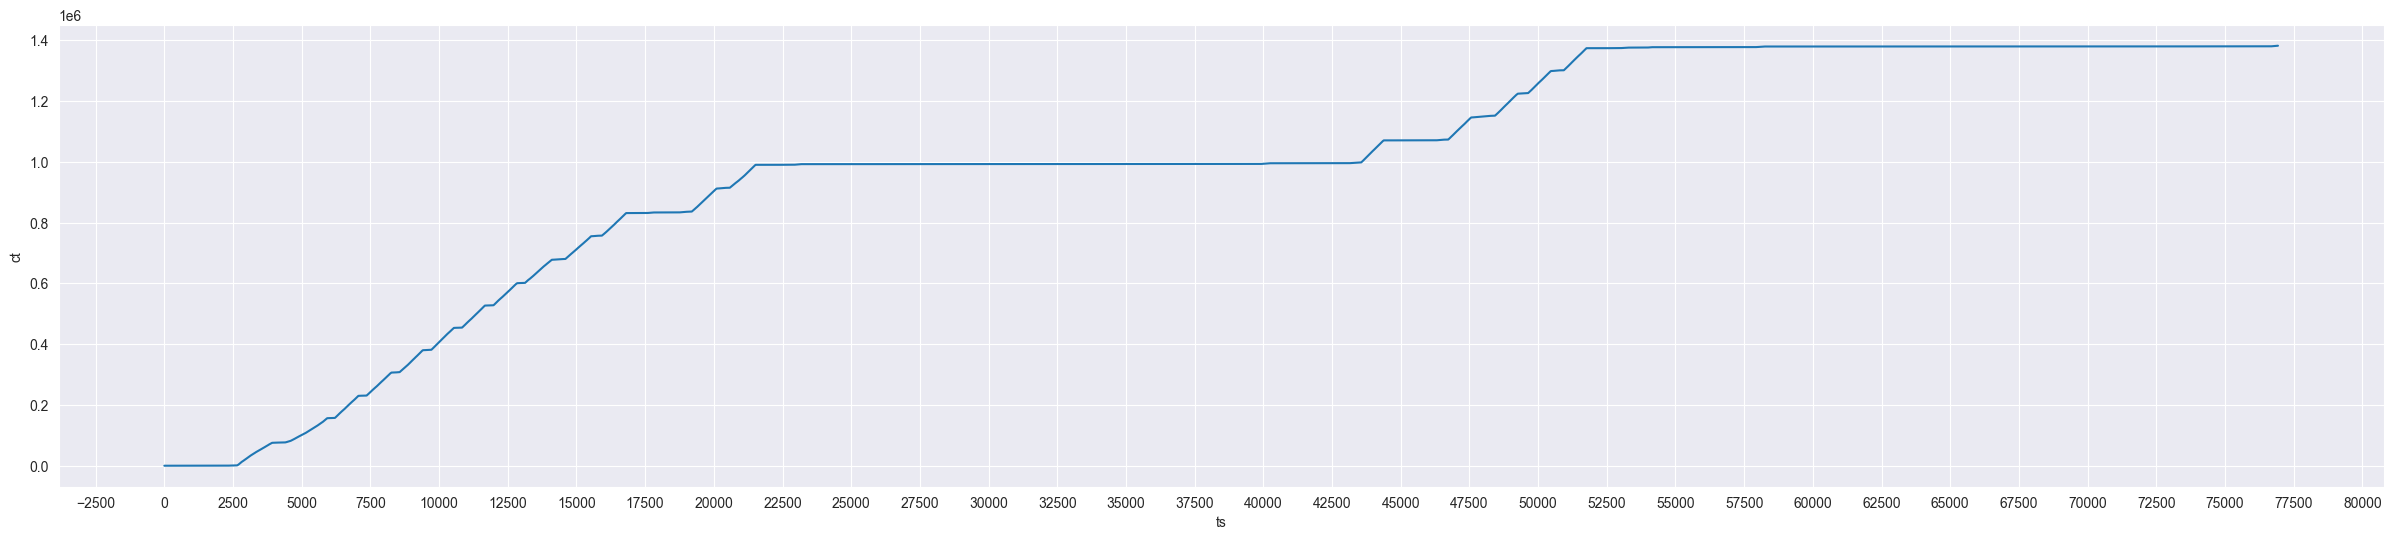

In [199]:

draw_line(df, 'ct')


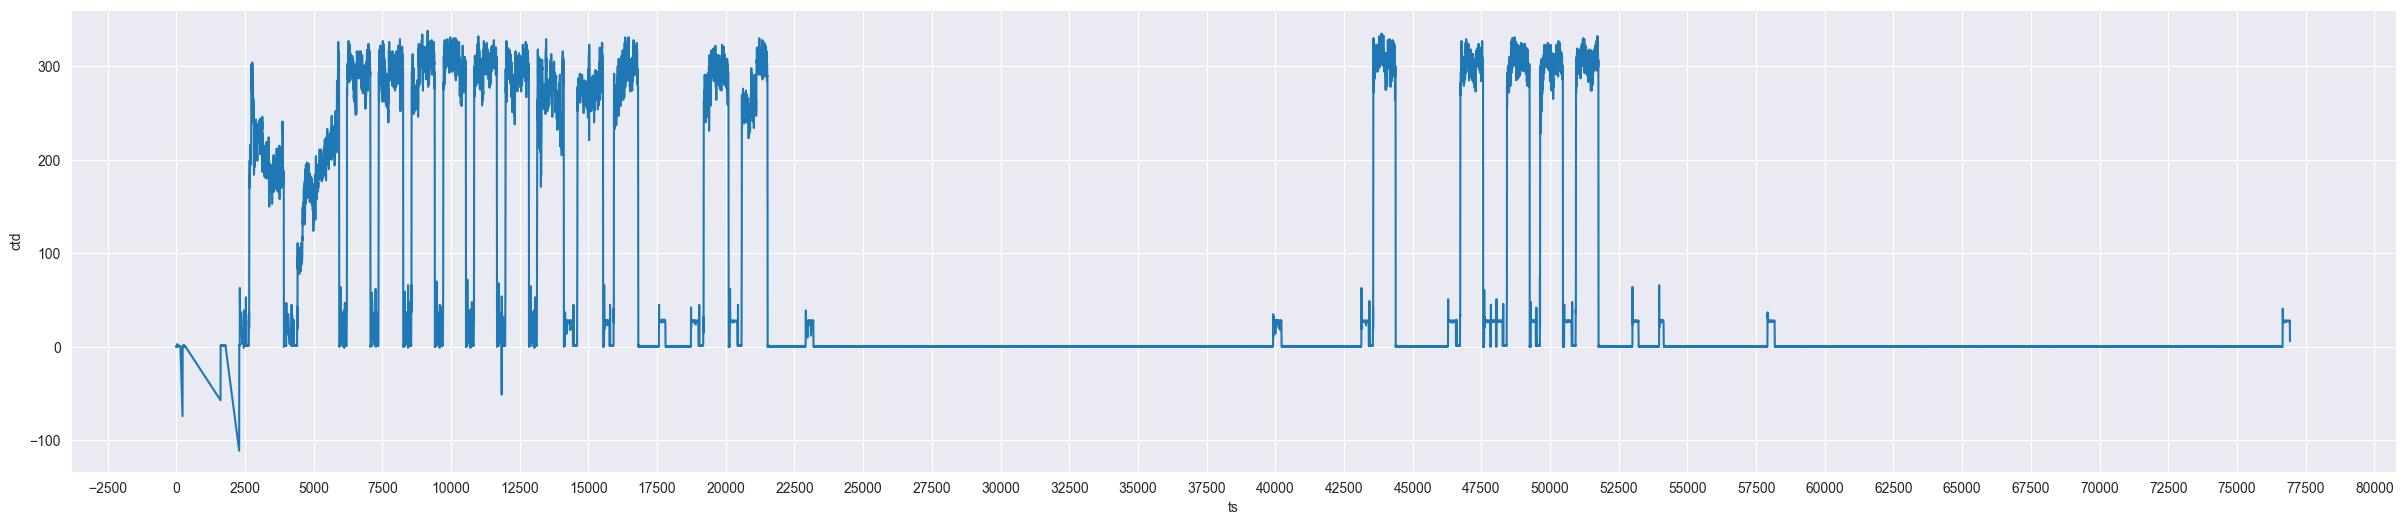

In [181]:
draw_line(df, 'ctd')


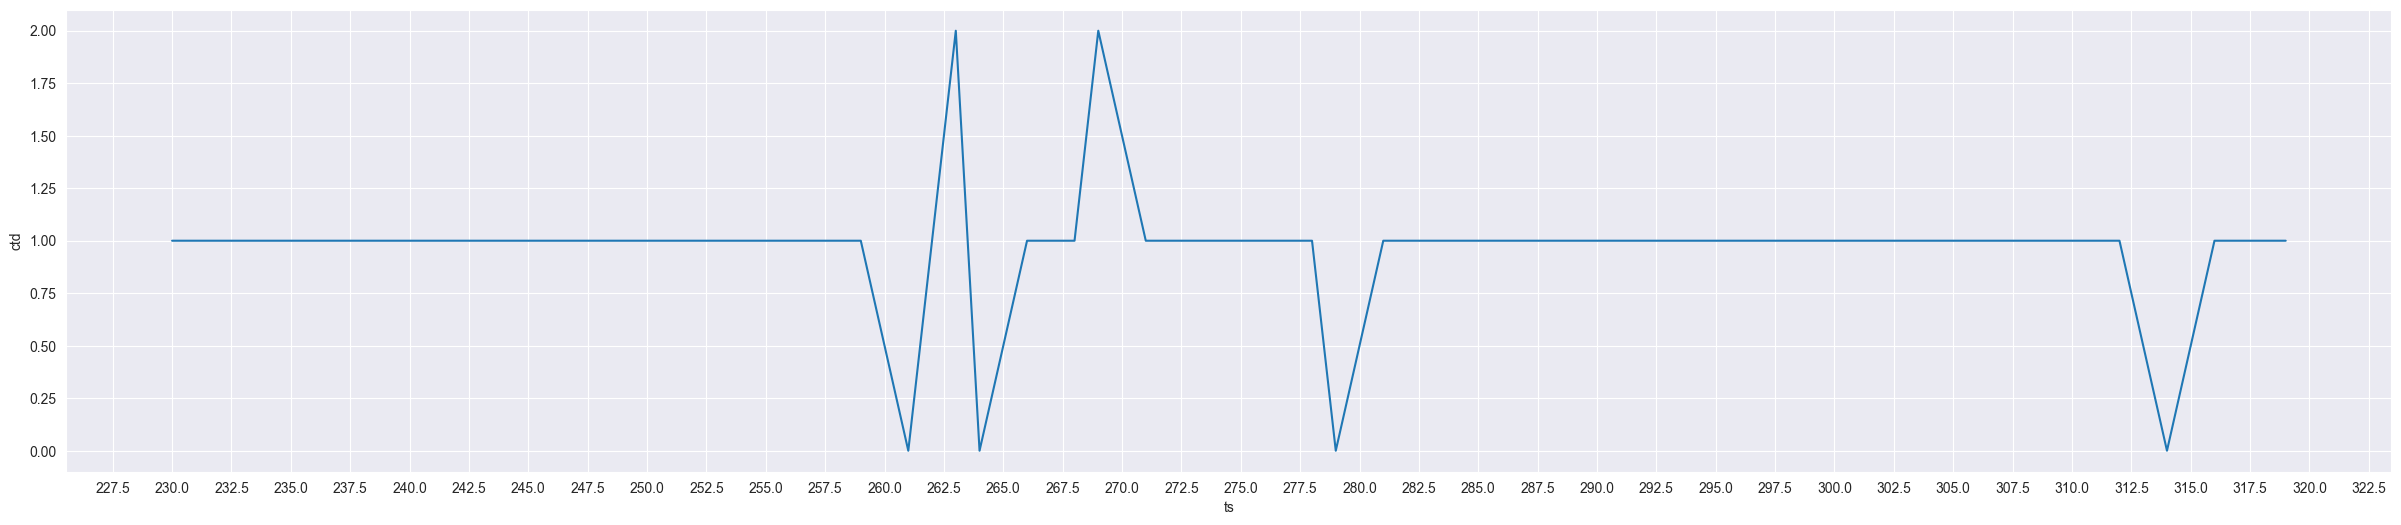

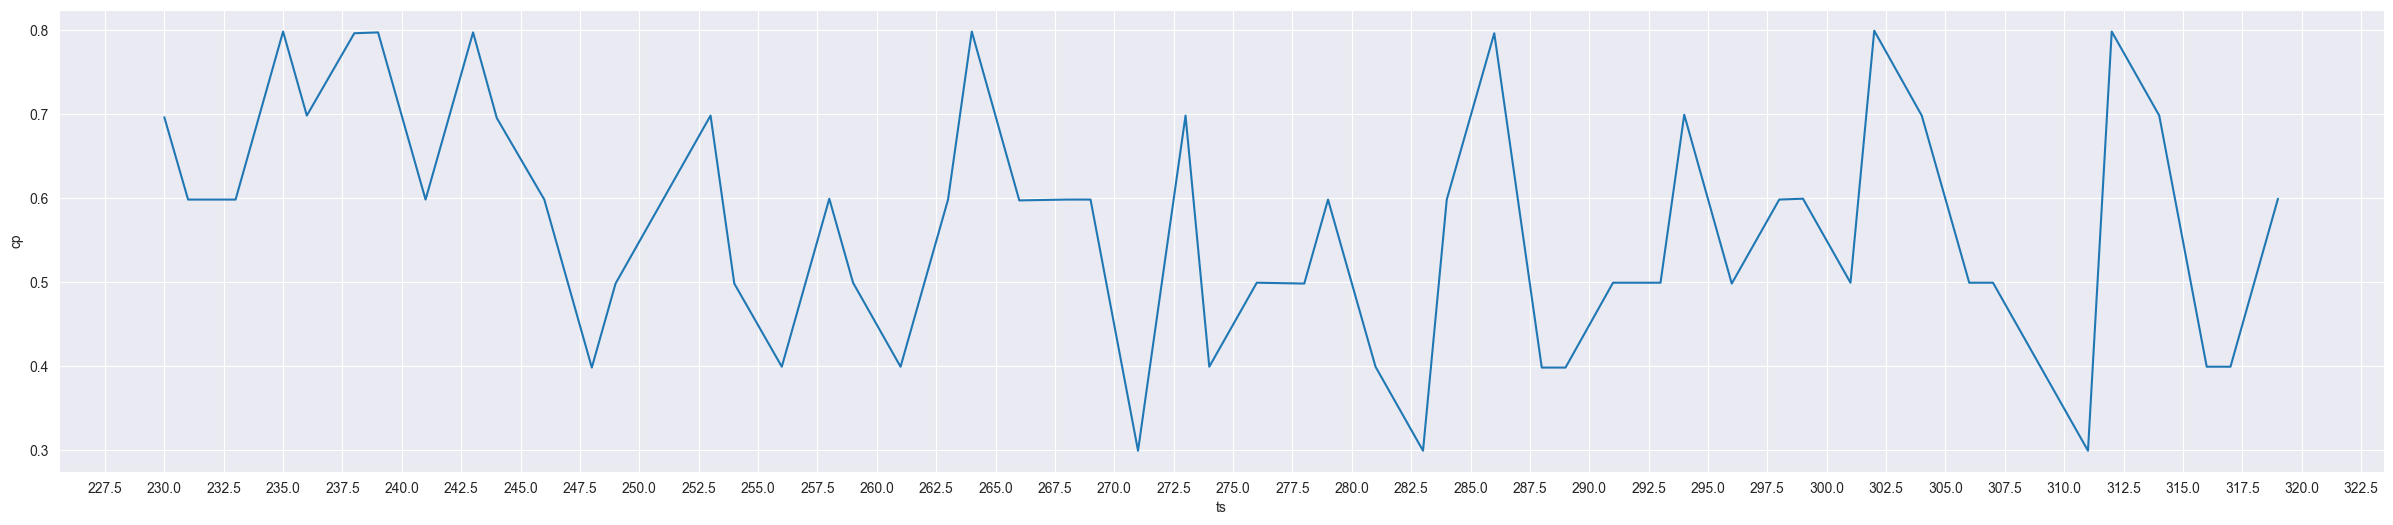

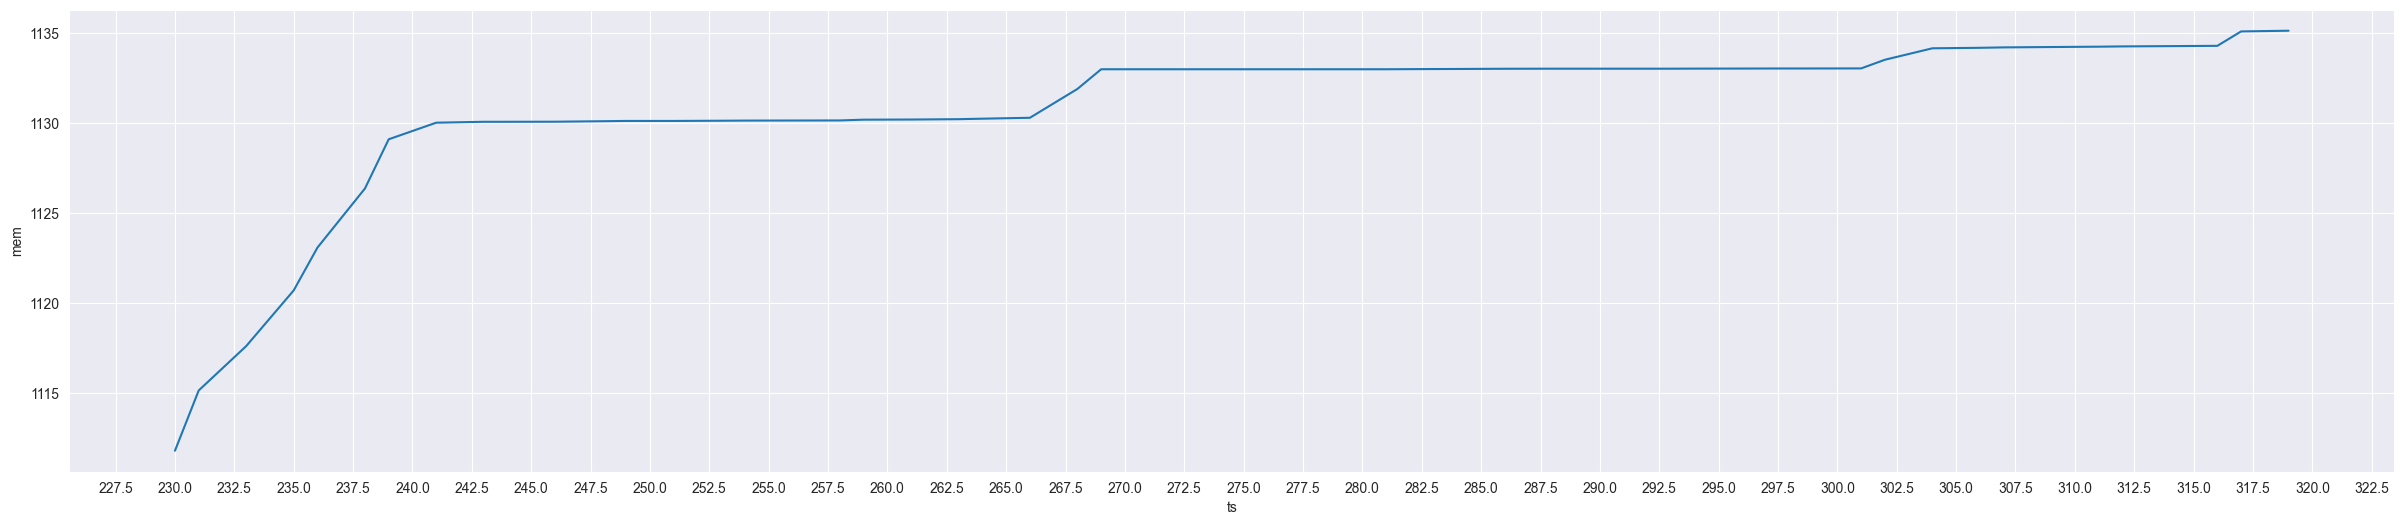

In [203]:

# for i in range(1, len(starts)):
#     start = starts[i - 1]
#     end = starts[i]
#     draw_line(get_range(df, start + 1, end - 1), "ctd")

i = 2
start = starts[i - 1]
end = starts[i]
ds = get_range(df, start + 1, end - 1)
# ds = ds[ds['ctd'] > 4]
draw_line(ds, "ctd")
draw_line(ds, "cp")
draw_line(ds, "mem")
# ds




In [ ]:
df.sort_values(by=["ct"])
# df[df['ct'] < 40]